<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Beginner_Friendly_Practice_Set_(_Optional_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instructions:**
- প্রতিটি cell এ `# YOUR CODE HERE` এর জায়গায় তোমার code লেখো।
- Expected output এর সাথে নিজের output মেলাও।
- `Shift + Enter` দিয়ে cell run করো।

---

## ⚙️ Setup — Run This First

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

np.random.seed(42)
data = {
    'Age':        [25, 32, np.nan, 45, 28, 60, 22, 38, np.nan, 55, 29, 200, 34, 41, 26],
    'Salary':     [30000, 55000, 48000, np.nan, 32000, 75000, 28000, 60000, 41000, 70000, 33000, 52000, np.nan, 63000, 29000],
    'City':       ['Dhaka','Chittagong','Dhaka','Sylhet',np.nan,'Dhaka','Rajshahi','Chittagong','Dhaka','Sylhet','Rajshahi','Dhaka','Chittagong',np.nan,'Dhaka'],
    'Education':  ['HSC','Graduate','Graduate','Masters','HSC','PhD','HSC','Graduate','Masters','PhD','HSC','Graduate','Graduate','Masters','HSC'],
    'Experience': [2, 8, 5, 15, 3, 30, 1, 12, 7, 25, 2, 9, 6, 18, 3],
    'Purchased':  [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0]
}
df = pd.DataFrame(data)
print('Dataset loaded! Shape:', df.shape)
df.head()

Dataset loaded! Shape: (15, 6)


,Age,Salary,City,Education,Experience,Purchased
0,25.0,30000.0,Dhaka,HSC,2,0
1,32.0,55000.0,Chittagong,Graduate,8,1
2,NaN,48000.0,Dhaka,Graduate,5,1
3,45.0,NaN,Sylhet,Masters,15,1
4,28.0,32000.0,NaN,HSC,3,0


---
# 📌 Section 1: Exploratory Data Analysis
**Module 01 & 02**

### 🟢 EASY &nbsp;&nbsp; Question 1
Dataset এর **shape** বের করো — কতটি row এবং column আছে?

In [3]:
# YOUR CODE HERE
# Hint: df.shape
df.shape

(15, 6)

**Expected Output:** `(15, 6)`

### 🟢 EASY &nbsp;&nbsp; Question 2
প্রতিটি column এর **data type** দেখাও।

In [4]:
# YOUR CODE HERE
# Hint: df.dtypes
df.dtypes

,0
Age,float64
Salary,float64
City,object
Education,object
Experience,int64
Purchased,int64


### 🟢 EASY &nbsp;&nbsp; Question 3
Dataset এর **statistical summary** দেখাও — mean, std, min, max।

In [5]:
# YOUR CODE HERE
# Hint: df.describe()
df.describe()

,Age,Salary,Experience,Purchased
count,13.000000,13.000000,15.000000,15.000000
mean,48.846154,47384.615385,9.733333,0.600000
std,46.857668,16474.922668,8.778762,0.507093
min,22.000000,28000.000000,1.000000,0.000000
25%,28.000000,32000.000000,3.000000,0.000000
50%,34.000000,48000.000000,7.000000,1.000000
75%,45.000000,60000.000000,13.500000,1.000000
max,200.000000,75000.000000,30.000000,1.000000


### 🟢 EASY &nbsp;&nbsp; Question 4
**City** column এ কতটি unique value আছে এবং প্রতিটি কতবার আসে?

In [6]:
# YOUR CODE HERE
# Hint: .nunique() এবং .value_counts()
df.nunique().value_counts(normalize=True)

,proportion
13,0.500000
4,0.333333
2,0.166667


### 🟡 MEDIUM &nbsp;&nbsp; Question 5
**Age** column এর mean, median এবং mode আলাদাভাবে বের করো এবং তিনটি একসাথে print করো।

In [7]:
# YOUR CODE HERE
# Hint: .mean(), .median(), .mode()[0]
age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_mode = df['Age'].mode()

print(f"Mean: {age_mean} \n, Median: {age_median} \n, Mode: {age_mode}")

Mean: 48.84615384615385 
, Median: 34.0 
, Mode: 0      22.0
1      25.0
2      26.0
3      28.0
4      29.0
5      32.0
6      34.0
7      38.0
8      41.0
9      45.0
10     55.0
11     60.0
12    200.0
Name: Age, dtype: float64


### 🟡 MEDIUM &nbsp;&nbsp; Question 6
**Age** এর distribution দেখানোর জন্য histogram plot করো। Title এবং axis labels দাও।

Text(0.5, 1.0, 'Age Distribution')

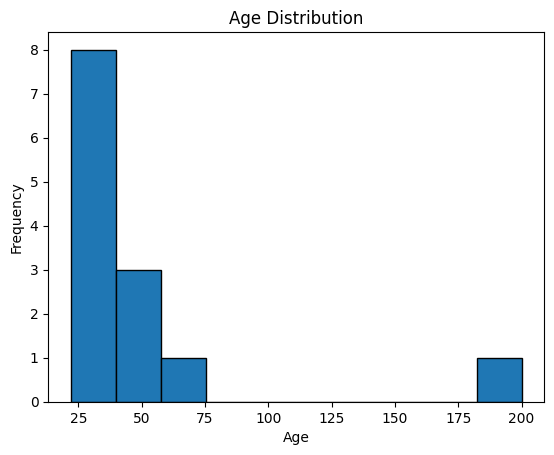

In [8]:
# YOUR CODE HERE
# Hint: plt.hist() বা df['Age'].plot(kind='hist')
# plt.title(), plt.xlabel(), plt.ylabel() দিতে ভুলো না
plt.hist(data = df, x = 'Age', edgecolor = 'black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

### 🟡 MEDIUM &nbsp;&nbsp; Question 7
**Salary vs Experience** scatter plot করো এবং দেখো কোনো pattern আছে কিনা।

<Axes: xlabel='Experience', ylabel='Salary'>

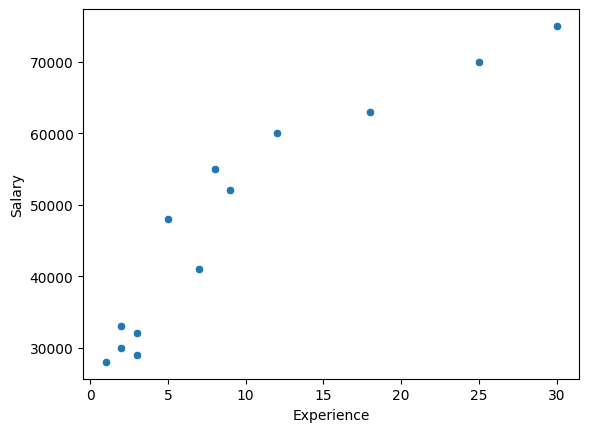

In [9]:
# YOUR CODE HERE
# Hint: sns.scatterplot(data=df, x='Experience', y='Salary')
sns.scatterplot(data=df, x='Experience', y='Salary')

### 🔴 HARD &nbsp;&nbsp; Question 8
Numerical columns এর correlation বের করো এবং **heatmap** দিয়ে visualize করো। `annot=True` দাও।

> চিন্তা করো: Age এবং Experience এর মধ্যে কি strong correlation আছে? কেন?

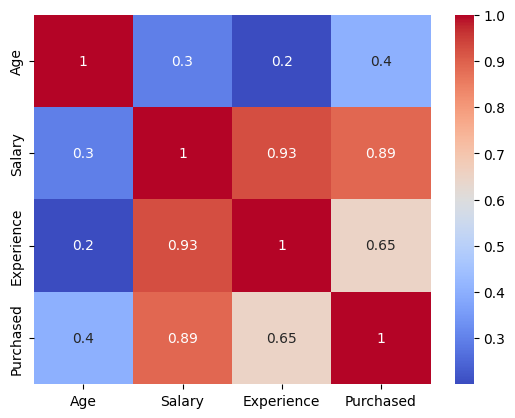

In [10]:
# YOUR CODE HERE
# Hint: df.corr() → sns.heatmap(..., annot=True, cmap='coolwarm')
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
plt.show()

---
# 📌 Section 2: Train-Test Split & Missing Value Handling
**Module 03**

### 🟢 EASY &nbsp;&nbsp; Question 9
প্রতিটি column এ **কতটি missing value** আছে তা বের করো।

In [11]:
# YOUR CODE HERE
# Hint: .isnull().sum()
df.isnull().sum()

,0
Age,2
Salary,2
City,2
Education,0
Experience,0
Purchased,0


**Expected:** Age=2, Salary=2, City=2

### 🟢 EASY &nbsp;&nbsp; Question 10
**Age** এর missing values **mean** দিয়ে এবং **City** এর missing values **mode** দিয়ে fill করো।

In [12]:
df_clean = df.copy()

# YOUR CODE HERE
# Age → mean
age_mean = df_clean['Age'].mean()
df_clean['Age'] = df_clean['Age'].fillna(age_mean)

# City → mode
city_mode = df_clean['City'].mode()[0]
df_clean['City'] = df_clean['City'].fillna(city_mode)

df_clean

,Age,Salary,City,Education,Experience,Purchased
0,25.000000,30000.0,Dhaka,HSC,2,0
1,32.000000,55000.0,Chittagong,Graduate,8,1
2,48.846154,48000.0,Dhaka,Graduate,5,1
3,45.000000,NaN,Sylhet,Masters,15,1
4,28.000000,32000.0,Dhaka,HSC,3,0
5,60.000000,75000.0,Dhaka,PhD,30,1
6,22.000000,28000.0,Rajshahi,HSC,1,0
7,38.000000,60000.0,Chittagong,Graduate,12,1
8,48.846154,41000.0,Dhaka,Masters,7,0
9,55.000000,70000.0,Sylhet,PhD,25,1


### 🟡 MEDIUM &nbsp;&nbsp; Question 11
**Salary** এর missing values **median** দিয়ে fill করো। Fill করার আগে ও পরে missing count দেখাও।

In [13]:
# YOUR CODE HERE
# Before count print করো
print('Before:', df['Salary'].isnull().sum())

# Fill করো
salary_median = df['Salary'].median()
df['Salary'] = df['Salary'].fillna(salary_median)

# After count print করো
print('Before:', df['Salary'].isnull().sum())

Before: 2
Before: 0


### 🟡 MEDIUM &nbsp;&nbsp; Question 12
**Train-Test Split** করো — 80% training, 20% testing। `random_state=42`।

> Feature (X): Age, Salary, Experience | Target (y): Purchased

In [14]:
X = df_clean[['Age', 'Salary', 'Experience']]
y = df_clean['Purchased']

# YOUR CODE HERE
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Print sizes
print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 12
Test size: 3


**Expected:** Train size: 12, Test size: 3

### 🔴 HARD &nbsp;&nbsp; Question 13
Train-Test Split করার পরে `y_train` এবং `y_test` এ **class distribution** (0 এবং 1 এর ratio) দেখাও। Distribution কি balanced?

> Hint: `.value_counts(normalize=True)` দিয়ে percentage বের করো।

In [15]:
# YOUR CODE HERE
# y_train distribution
y_train_dist = y_train.value_counts(normalize=True)
print('y train distribution: \n', y_train_dist)

print()
# y_test distribution
y_test_dist = y_test.value_counts(normalize=True)
print('y test distribution: \n', y_test_dist)

# তোমার observation লেখো (comment এ):
# If the distribution is 50/50 that is balanced but in this case, the y train distribution is less than y test distribution which is imbalanced

# "Train এ class 0 আছে X%, class 1 আছে Y%..."

y train distribution: 
 Purchased
1    0.583333
0    0.416667
Name: proportion, dtype: float64

y test distribution: 
 Purchased
1    0.666667
0    0.333333
Name: proportion, dtype: float64


---
# 📌 Section 3: Outlier Detection and Handling
**Module 05 & 06**

### 🟢 EASY &nbsp;&nbsp; Question 14
**Age** column এর **boxplot** তৈরি করো।

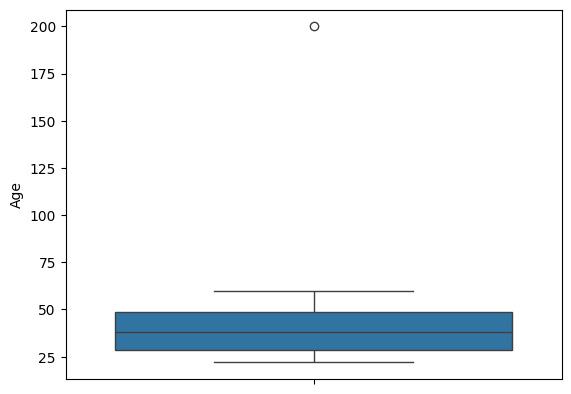

In [16]:
# YOUR CODE HERE
# Hint: sns.boxplot(y=df_clean['Age'])
sns.boxplot(y=df_clean['Age'])
plt.show()

**Note:** Age=200 clearly একটি outlier।

### 🟡 MEDIUM &nbsp;&nbsp; Question 15
**IQR Method** দিয়ে **Age** column এর outlier detect করো এবং outlier rows দেখাও।

> IQR = Q3 - Q1 | Lower = Q1 - 1.5×IQR | Upper = Q3 + 1.5×IQR

In [17]:
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)

# YOUR CODE HERE
# IQR calculate করো
IQR = Q3 - Q1
# Lower এবং Upper bound
Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

# Outlier rows দেখাও
Outlier = df_clean[(df_clean['Age'] < Lower) | (df_clean['Age'] > Upper)]
print('Outlier Rows:', len(Outlier))

Outlier Rows: 1


**Expected:** Age=200 row outlier হিসেবে detected হবে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 16
**Z-Score Method** দিয়ে outlier detect করো। |Z| > 3 হলে outlier।

> Z = (x - mean) / std

In [18]:
# YOUR CODE HERE
mean_age = df_clean['Age'].mean()
std_age  = df_clean['Age'].std()

# Z-score calculate করো
df_clean['Z_score_Age'] = (df_clean['Age'] - mean_age) / std_age

# |Z| > 3 এমন rows দেখাও
Z_score_outlier = df_clean[abs(df_clean['Z_score_Age']) > 3]
print('Total Z-Score Outlier:', len(Z_score_outlier))

Total Z-Score Outlier: 1


### 🟡 MEDIUM &nbsp;&nbsp; Question 17
IQR method এ detected outlier rows **remove** করো। নতুন shape দেখাও।

In [19]:
# YOUR CODE HERE
# Hint: bound এর মধ্যে আছে এমন rows রাখো
df_clean = df_clean.drop('Z_score_Age', axis = 1)

df_clean = df_clean[(df_clean['Age'] >= Lower) & (df_clean['Age'] <= Upper)]
print('New shape:', df_clean.shape)

New shape: (14, 6)


**Expected:** Shape (14, 6) — 1 row removed.

### 🔴 HARD &nbsp;&nbsp; Question 18
Outlier remove করার বদলে **cap** করো (Winsorization)। তারপর before vs after boxplot side-by-side দেখাও।

> Cap মানে: outlier value কে bound এর value দিয়ে replace করা।

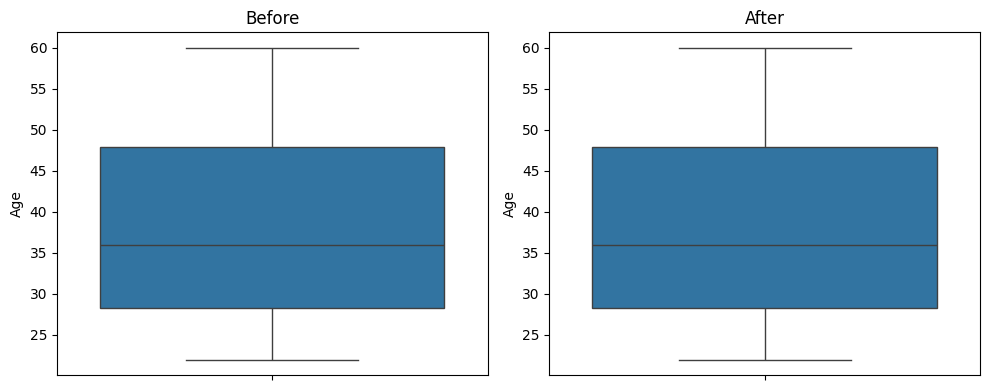

In [20]:
df_capped = df_clean.copy()

# YOUR CODE HERE
# Step 1: Cap করো
# Hint: df_capped['Age'] = df_capped['Age'].clip(lower=lower_bound, upper=upper_bound)
df_capped['Age'] = df_capped['Age'].clip(Lower, Upper)

# Step 2: Before vs After boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data = df_clean, y = 'Age', ax = axes[0]).set_title('Before')
sns.boxplot(data = df_capped, y = 'Age', ax = axes[1]).set_title('After')
# axes[0] → Before (df_clean)
# axes[1] → After (df_capped)
plt.tight_layout()
plt.show()

---
# 📌 Section 4: Encoding
**Module 07**

### 🟢 EASY &nbsp;&nbsp; Question 19
**Label Encoding** দিয়ে **Education** column কে numerical করো।

In [21]:
df_encoded = df_clean.copy()
le = LabelEncoder()

# YOUR CODE HERE
# df_encoded['Education_Encoded'] = le.fit_transform(...)
df_encoded['Education_Encoded'] = le.fit_transform(df_encoded['Education'])
df_encoded

,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,30000.0,Dhaka,HSC,2,0,1
1,32.000000,55000.0,Chittagong,Graduate,8,1,0
2,48.846154,48000.0,Dhaka,Graduate,5,1,0
3,45.000000,NaN,Sylhet,Masters,15,1,2
4,28.000000,32000.0,Dhaka,HSC,3,0,1
5,60.000000,75000.0,Dhaka,PhD,30,1,3
6,22.000000,28000.0,Rajshahi,HSC,1,0,1
7,38.000000,60000.0,Chittagong,Graduate,12,1,0
8,48.846154,41000.0,Dhaka,Masters,7,0,2
9,55.000000,70000.0,Sylhet,PhD,25,1,3


### 🟢 EASY &nbsp;&nbsp; Question 20
**One-Hot Encoding** দিয়ে **City** column কে encode করো। `pd.get_dummies()` ব্যবহার করো।

In [22]:
# YOUR CODE HERE
# Hint: pd.get_dummies(df_encoded, columns=['City'], drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=['City'], drop_first=True)
df_encoded

,Age,Salary,Education,Experience,Purchased,Education_Encoded,City_Dhaka,City_Rajshahi,City_Sylhet
0,25.000000,30000.0,HSC,2,0,1,True,False,False
1,32.000000,55000.0,Graduate,8,1,0,False,False,False
2,48.846154,48000.0,Graduate,5,1,0,True,False,False
3,45.000000,NaN,Masters,15,1,2,False,False,True
4,28.000000,32000.0,HSC,3,0,1,True,False,False
5,60.000000,75000.0,PhD,30,1,3,True,False,False
6,22.000000,28000.0,HSC,1,0,1,False,True,False
7,38.000000,60000.0,Graduate,12,1,0,False,False,False
8,48.846154,41000.0,Masters,7,0,2,True,False,False
9,55.000000,70000.0,PhD,25,1,3,False,False,True


**Note:** `drop_first=True` দিলে dummy variable trap avoid হয়।

### 🟡 MEDIUM &nbsp;&nbsp; Question 21
Label Encoded **Education** এর mapping dictionary দেখাও — কোন label কোন number পেয়েছে।

In [23]:
# YOUR CODE HERE
# Hint: dict(zip(le.classes_, le.transform(le.classes_)))
dict(zip(le.classes_, range(len(le.classes_))))

{'Graduate': 0, 'HSC': 1, 'Masters': 2, 'PhD': 3}

**Expected:** `{'Graduate': 0, 'HSC': 1, 'Masters': 2, 'PhD': 3}`

### 🔴 HARD &nbsp;&nbsp; Question 22
Label Encoding এবং One-Hot Encoding এর মধ্যে পার্থক্য কী? **Education** column এ কোনটা ব্যবহার করা সঠিক এবং কেন?

> দুটো method ই apply করো এবং output compare করো। তারপর নিচে comment এ তোমার reasoning লেখো।

In [24]:
# Method 1: Label Encoding
le = LabelEncoder()
df['Label_Edu'] = le.fit_transform(df['Education'])

# Method 2: One-Hot Encoding
edu_ohe = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore').set_output(transform = 'pandas')
edu_encoded = edu_ohe.fit_transform(df[['Education']])
df = pd.concat([df, edu_encoded], axis = 1)
df

# তোমার answer (comment এ লেখো):
# Label Encoding converts categorical values into a sequence of integers within a single column, whereas One-Hot Encoding splits categories into multiple new binary (0 or 1) columns

# Education column এ OneHotEncoder ভালো কারণ it splits categories into multiple new columns which is easy to train and understand.


,Age,Salary,City,Education,Experience,Purchased,Label_Edu,Education_Graduate,Education_HSC,Education_Masters,Education_PhD
0,25.0,30000.0,Dhaka,HSC,2,0,1,0.0,1.0,0.0,0.0
1,32.0,55000.0,Chittagong,Graduate,8,1,0,1.0,0.0,0.0,0.0
2,NaN,48000.0,Dhaka,Graduate,5,1,0,1.0,0.0,0.0,0.0
3,45.0,48000.0,Sylhet,Masters,15,1,2,0.0,0.0,1.0,0.0
4,28.0,32000.0,NaN,HSC,3,0,1,0.0,1.0,0.0,0.0
5,60.0,75000.0,Dhaka,PhD,30,1,3,0.0,0.0,0.0,1.0
6,22.0,28000.0,Rajshahi,HSC,1,0,1,0.0,1.0,0.0,0.0
7,38.0,60000.0,Chittagong,Graduate,12,1,0,1.0,0.0,0.0,0.0
8,NaN,41000.0,Dhaka,Masters,7,0,2,0.0,0.0,1.0,0.0
9,55.0,70000.0,Sylhet,PhD,25,1,3,0.0,0.0,0.0,1.0


---
# 📌 Section 5: Scaling
**Module 08**

### 🟢 EASY &nbsp;&nbsp; Question 23
**MinMaxScaler** দিয়ে **Experience** column কে 0–1 এর মধ্যে scale করো।

> Formula: x_scaled = (x - min) / (max - min)

In [32]:
mm_scaler = MinMaxScaler()
df_scaled  = df_clean.copy()

# YOUR CODE HERE
df_scaled['Experience'] = mm_scaler.fit_transform(df_scaled[['Experience']])
df_scaled['Experience']

,Experience
0,0.034483
1,0.241379
2,0.137931
3,0.482759
4,0.068966
5,1.000000
6,0.000000
7,0.379310
8,0.206897
9,0.827586


**Expected:** Experience values এখন 0.0 থেকে 1.0 এর মধ্যে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 24
**StandardScaler** দিয়ে **Age** এবং **Salary** scale করো। Scaling এর পর mean ≈ 0 এবং std ≈ 1 verify করো।

In [38]:
std_scaler = StandardScaler()

# YOUR CODE HERE
# Scale করো
df_cols = ['Age', 'Salary']

for cols in df_cols:
  df_clean[cols] = std_scaler.fit_transform(df_clean[[cols]])

# Verify: mean এবং std print করো
  print('Mean:', round((df_clean[cols].mean()), 2))
  print('Std:', round((df_clean[cols].std()), 2))

Mean: -0.0
Std: 1.04
Mean: 0.0
Std: 1.04


**Expected:** Mean ≈ 0.0, Std ≈ 1.0

### 🟡 MEDIUM &nbsp;&nbsp; Question 25
**Age** column এর scaling এর আগে ও পরে distribution **side-by-side histogram** দিয়ে compare করো।

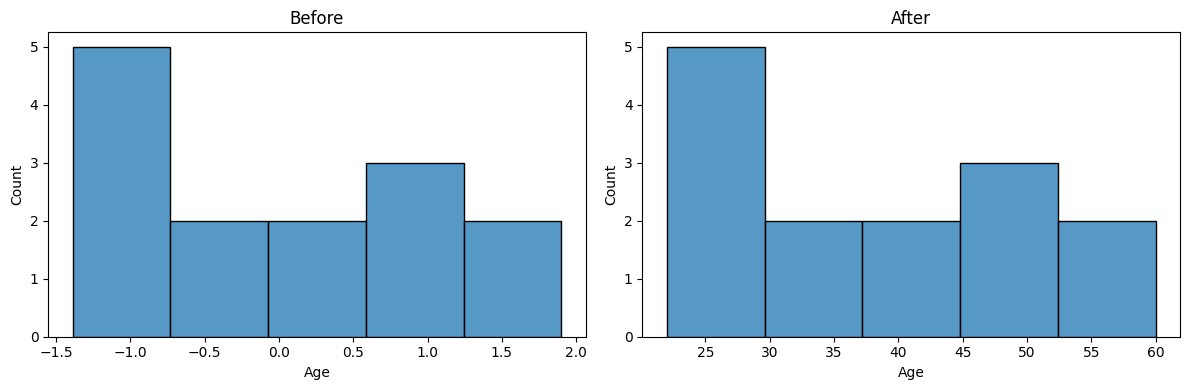

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# YOUR CODE HERE
# axes[0] → Before scaling
# axes[1] → After scaling
sns.histplot(data = df_clean, x = 'Age', ax = axes[0]).set_title('Before')
sns.histplot(data = df_scaled, x = 'Age', ax = axes[1]).set_title('After')
plt.tight_layout()
plt.show()

### 🔴 HARD &nbsp;&nbsp; Question 26
StandardScaler এবং MinMaxScaler এর মধ্যে পার্থক্য কী? **Salary** column এ দুটোই apply করো এবং output compare করো।

> কোন situation এ কোনটা use করবে? Comment এ reasoning লেখো।

In [41]:
salary = df_clean[['Salary']]

# StandardScaler apply করো
ss = StandardScaler()
sal_ss_scaled = ss.fit_transform(salary)

# MinMaxScaler apply করো
mm = MinMaxScaler()
sal_mm_scaled = mm.fit_transform(salary)

# দুটো result compare করো (print অথবা plot)
print('Standard Scaler:', sal_ss_scaled)
print('MinMaxScaler:', sal_mm_scaled)

# StandardScaler: mean=0, std=1 — works well when data has outliers
# MinMaxScaler: scales between 0 and 1 — works well when data has no outliers
# Salary column এ StandardScaler ভালো কারণ Salary usually has outliers, MinMaxScaler gets distorted by outliers because it uses min and max values

Standard Scaler: [[-1.03554634]
 [ 0.48731592]
 [ 0.06091449]
 [        nan]
 [-0.91371736]
 [ 1.70560573]
 [-1.15737532]
 [ 0.79188838]
 [-0.36548694]
 [ 1.40103328]
 [-0.85280287]
 [        nan]
 [ 0.97463185]
 [-1.09646083]]
MinMaxScaler: [[0.04255319]
 [0.57446809]
 [0.42553191]
 [       nan]
 [0.08510638]
 [1.        ]
 [0.        ]
 [0.68085106]
 [0.27659574]
 [0.89361702]
 [0.10638298]
 [       nan]
 [0.74468085]
 [0.0212766 ]]


---
# 🌟 Bonus: Full Pipeline
**Combine everything — end-to-end preprocessing**

### 🔴 HARD &nbsp;&nbsp; Question 27 (Bonus)
নিচের সব steps follow করে একটি **complete preprocessing pipeline** তৈরি করো:

1. Missing values handle করো
2. Outliers cap করো (IQR method)
3. City → One-Hot Encode
4. Education → Label Encode
5. Age, Salary, Experience → StandardScale
6. 80/20 Train-Test Split
7. Final train/test shape print করো

In [92]:
df_pipeline = df.copy()

# Step 1: Missing values
num_imputer = SimpleImputer(strategy='mean')
df_pipeline[['Age', 'Salary']] = num_imputer.fit_transform(df_pipeline[['Age', 'Salary']])
cat_imputer = SimpleImputer(strategy='most_frequent')
df_pipeline['City'] = cat_imputer.fit_transform(df_pipeline[['City']]).ravel()

# Step 2: Outlier capping (IQR)
for col in ['Age', 'Salary', 'Experience']:
    Q1 = df_pipeline[col].quantile(0.25)
    Q3 = df_pipeline[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_pipeline[col] = df_pipeline[col].clip(lower, upper)

# Step 3: One-Hot Encoding
# 1st way
# df_pipeline = pd.get_dummies(df_pipeline, columns=['City'], drop_first=True)

# 2nd way
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
city_encoded = ohe.fit_transform(df_pipeline[['City']])
df_pipeline = pd.concat([df_pipeline.drop(columns=['City']), city_encoded], axis=1)

# Step 4: Label Encoding
le = LabelEncoder()
df_pipeline['Education'] = le.fit_transform(df_pipeline['Education'])

# Step 5: Standard Scaling
ss = StandardScaler()
df_pipeline[['Age', 'Salary', 'Experience']] = ss.fit_transform(df_pipeline[['Age', 'Salary', 'Experience']])

# Step 6: Train-Test Split
X = df_pipeline.drop(columns=['Purchased'])
y = df_pipeline['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Print shapes
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Pipeline complete!')

X_train shape: (12, 8)
X_test shape: (3, 8)
Pipeline complete!
